In [ ]:
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
distances = np.array([
    [0, 2, 9, 10, 7],
    [2, 0, 6, 4, 3],
    [9, 6, 0, 8, 5],
    [10, 4, 8, 0, 6],
    [7, 3, 5, 6, 0]
])

n_cities = len(distances)

In [ ]:
n_ants = 10
n_iterations = 50
alpha = 1
beta = 2
evaporation = 0.5
Q = 100

In [5]:
pheromone = np.ones((n_cities, n_cities))
pheromone

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [6]:
def calculate_distance(path):
    return sum(distances[path[i]][path[i+1]]
               for i in range(len(path)-1)) \
           + distances[path[-1]][path[0]]

In [7]:
global_best_distance = float("inf")
global_best_path = None

In [8]:
for iteration in range(n_iterations):

    all_paths = []
    all_distances = []

    for ant in range(n_ants):

        visited = [random.randint(0, n_cities - 1)]

        while len(visited) < n_cities:
            current = visited[-1]
            probabilities = []

            for city in range(n_cities):
                if city not in visited:
                    tau = pheromone[current][city] ** alpha
                    eta = (1 / distances[current][city]) ** beta
                    probabilities.append(tau * eta)
                else:
                    probabilities.append(0)

            probabilities = np.array(probabilities)
            probabilities /= probabilities.sum()

            next_city = np.random.choice(range(n_cities), p=probabilities)
            visited.append(next_city)

        distance = calculate_distance(visited)

        all_paths.append(visited)
        all_distances.append(distance)

        if distance < global_best_distance:
            global_best_distance = distance
            global_best_path = visited


In [9]:
pheromone *= (1 - evaporation)

In [10]:
for path, dist in zip(all_paths, all_distances):
    for i in range(len(path) - 1):
        pheromone[path[i]][path[i+1]] += Q / dist
        pheromone[path[i+1]][path[i]] += Q / dist

    pheromone[path[-1]][path[0]] += Q / dist
    pheromone[path[0]][path[-1]] += Q / dist


In [11]:
print("Best Path:", global_best_path)
print("Best Distance:", global_best_distance)

Best Path: [4, np.int64(2), np.int64(0), np.int64(1), np.int64(3)]
Best Distance: 26


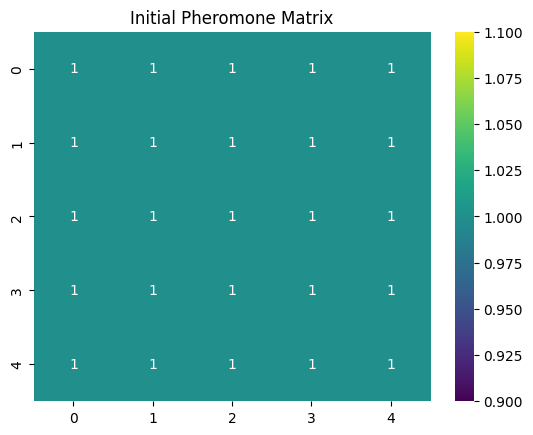

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(np.ones((n_cities, n_cities)), annot=True, cmap="viridis")
plt.title("Initial Pheromone Matrix")
plt.show()

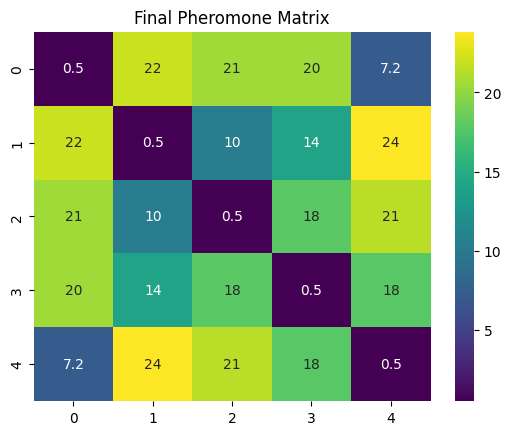

In [18]:
plt.figure()
sns.heatmap(pheromone, annot=True, cmap="viridis")
plt.title("Final Pheromone Matrix")
plt.show()